# Model Evaluation under Covariate Shift (Domain Adaptation)

In this notebook, we simulate a Non-Linear Covariate Shift using the `Two Moons` dataset.
We split the data into two domains with a deliberate overlap to act as an anchor:
* **Source Domain (ID):** Samples where $X \le 0$.
* **Target Domain (OOD):** Samples where $X \ge -0.1$.

We will evaluate multiple models (Linear, Tree-based, Neural Network, and TabPFN) to observe how their decision boundaries extrapolate into unseen data, and finally test if a linear alignment method (**CORAL**) can mitigate the shift.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from scipy.linalg import fractional_matrix_power
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier 
import os
import tabpfn_client # Uncomment if needed

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. Data Generation: Rotated Anisotropic Gaussians (Covariance Shift)
# ==========================================
np.random.seed(42)

# A. Generate Base Isotropic Gaussian Blobs
X_base_src, y_source_std = make_blobs(n_samples=500, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=0.8, random_state=42)
X_base_tgt, y_target_std = make_blobs(n_samples=500, centers=[[-1.5, -1.5], [1.5, 1.5]], cluster_std=0.8, random_state=42)

# B. Transform Source: Stretch into horizontal-ish ellipses
source_transformation = np.array([[2.0, -0.3], 
                                  [-0.3, 0.6]])
X_source_std = np.dot(X_base_src, source_transformation)

# C. Transform Target: Rotate by ~45 degrees, stretch differently, and apply a slight shift (Covariance Shift)
target_transformation = np.array([[1.2, 1.5], 
                                  [-1.2, 1.3]])
X_target_std = np.dot(X_base_tgt, target_transformation) + np.array([1.5, -0.5])

# D. Combine to maintain exact variable names for downstream cells
X_base_std = np.vstack((X_source_std, X_target_std))
y_base_std = np.hstack((y_source_std, y_target_std))

# Create masks for compatibility
source_mask = np.zeros(1000, dtype=bool)
source_mask[:500] = True
target_mask = ~source_mask

# ==========================================
# 2. General Evaluation Function
# ==========================================
def train_and_eval(model, X_train, y_train, X_test, y_test):
    """Trains the model and returns accuracies for both source and target."""
    model.fit(X_train, y_train)
    acc_src = accuracy_score(y_train, model.predict(X_train))
    acc_tgt = accuracy_score(y_test, model.predict(X_test))
    return acc_src, acc_tgt

### Visualizing the Covariate Shift

We first visualize the spatial distribution of the data to illustrate the simulated Domain Shift.

In the plot below, we visualize the entire `Two Moons` dataset. We then demarcate the domains:
* The area to the left (up to $X=0$) is our **Source Domain**. This is the only environment our models will see during training.
* The area to the right (starting from $X=-0.1$) is our **Target Domain**. 
* The highlighted yellow band represents the **Overlap Region** ($-0.1 \le X \le 0$). This shared geometric space acts as an anchor, giving the models a slight hint of the target distribution and helping alignment algorithms like CORAL to find a mapping between the domains.

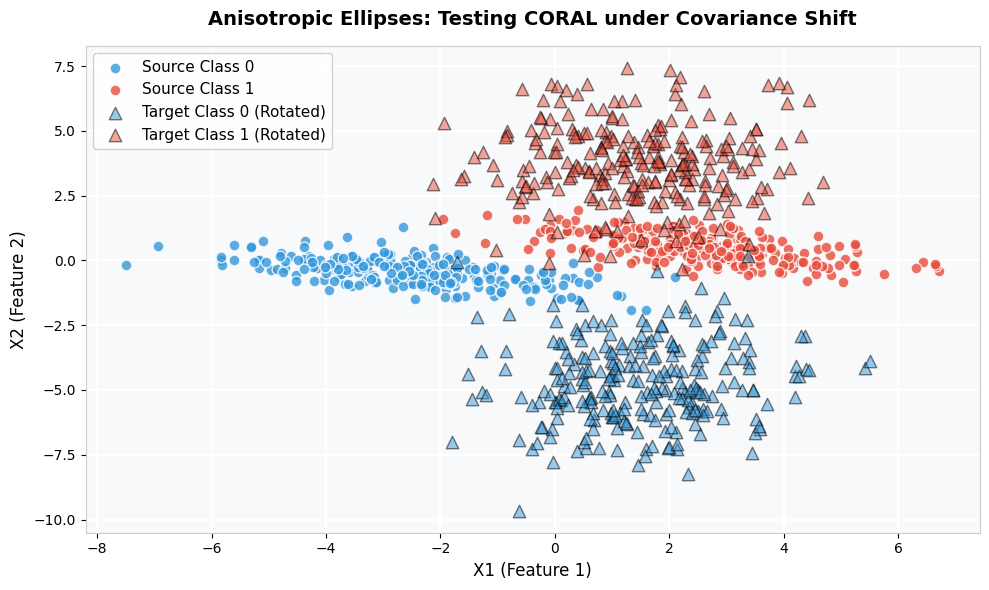

In [14]:
# ==========================================
# 3. Visualizing the Rotated Ellipses
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# Scatter Source (Circles) - Horizontal-ish ellipses
ax.scatter(X_source_std[y_source_std==0, 0], X_source_std[y_source_std==0, 1], 
           c=color_blue, marker='o', edgecolors='white', s=60, alpha=0.8, label='Source Class 0')
ax.scatter(X_source_std[y_source_std==1, 0], X_source_std[y_source_std==1, 1], 
           c=color_red, marker='o', edgecolors='white', s=60, alpha=0.8, label='Source Class 1')

# Scatter Target (Triangles) - Rotated and shifted ellipses
ax.scatter(X_target_std[y_target_std==0, 0], X_target_std[y_target_std==0, 1], 
           c=color_blue, marker='^', edgecolors='black', s=80, alpha=0.5, label='Target Class 0 (Rotated)')
ax.scatter(X_target_std[y_target_std==1, 0], X_target_std[y_target_std==1, 1], 
           c=color_red, marker='^', edgecolors='black', s=80, alpha=0.5, label='Target Class 1 (Rotated)')

# Aesthetics
ax.set_title("Anisotropic Ellipses: Testing CORAL under Covariance Shift", fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel("X1 (Feature 1)", fontsize=12)
ax.set_ylabel("X2 (Feature 2)", fontsize=12)
ax.set_facecolor('#f8f9fa')
ax.grid(True, color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)

# Clean borders
for spine in ax.spines.values():
    spine.set_color('#cccccc')

ax.legend(loc='best', fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.show()

## Base Models Evaluation

We will train standard classifiers exclusively on the Source Domain and test their generalization on the Target Domain.

### Linear Baselines: Standard Logistic Regression

We begin our evaluation with a standard linear model. Logistic Regression provides a highly interpretable baseline, learning a simple linear decision boundary. 

**The Importance of Feature Scaling:**
While our current dataset is low-dimensional (2D), we apply `StandardScaler` to normalize our features ($mean=0$, $variance=1$). This is a machine learning best practice that ensures stable and fast mathematical convergence for the solver. Furthermore, it sets up a robust pipeline for when we later introduce high-dimensional biological data and scale-sensitive regularization techniques.

In [4]:
# ==========================================
# 1. Feature Scaling
# ==========================================
# Fit scaler ONLY on Source domain to prevent data leakage
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source_std)
X_target_scaled = scaler.transform(X_target_std)

# ==========================================
# 2. Model Training
# ==========================================
lr_model = LogisticRegression(random_state=42)
lr_src_acc, lr_tgt_acc = train_and_eval(lr_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"Logistic Regression Accuracy on Source Data: {lr_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"Logistic Regression Accuracy on Target Data: {lr_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
Logistic Regression Accuracy on Source Data: 0.994

--- Target Domain (OOD) ---
Logistic Regression Accuracy on Target Data: 0.992



### Tree-Based Ensemble: XGBoost
Next, we evaluate XGBoost, a powerful gradient boosting framework. Unlike linear models, tree-based models learn decision boundaries through orthogonal splits (axis-parallel cuts). We expect a highly complex, step-like boundary that may overfit the Source domain and struggle to extrapolate smoothly into the curved Target domain.

In [5]:
# Initialize and train XGBoost
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_src_acc, xgb_tgt_acc = train_and_eval(xgb_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"XGBoost Accuracy on Source Data: {xgb_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"XGBoost Accuracy on Target Data: {xgb_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
XGBoost Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
XGBoost Accuracy on Target Data: 0.838



### Neural Networks: Multi-Layer Perceptron (MLP)

We evaluate the Multi-Layer Perceptron as our deep learning baseline. As a universal function approximator, an MLP with hidden layers can learn highly complex, smooth, and non-linear representations. 

**The Extrapolation Challenge:** We expect the MLP to perfectly "hug" the shape of the moons in the Source domain (ID), achieving near-perfect accuracy. However, standard neural networks are notoriously poor at out-of-distribution extrapolation. When presented with the Target domain (OOD) where the geometric trend of the moons inverts, the MLP's learned boundary will likely fail, highlighting the fundamental challenge of Covariate Shift for deep models.

In [6]:
# Initialize and train MLP
mlp_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

mlp_src_acc, mlp_tgt_acc = train_and_eval(mlp_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"MLP Accuracy on Source Data: {mlp_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"MLP Accuracy on Target Data: {mlp_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
MLP Accuracy on Source Data: 0.998

--- Target Domain (OOD) ---
MLP Accuracy on Target Data: 0.992



### Foundation Models: TabPFN
Finally, we test TabPFN, a Prior-Data Fitted Network that performs in-context learning for tabular data without traditional weight optimization. It relies on a Transformer architecture pre-trained on synthetic datasets. We test how an attention-based model handles Covariate Shift.

**Note on TabPFN Usage:**
Recent updates to the `tabpfn` library require a free API token to access the foundation model. To run the cell below locally:
1. Open https://ux.priorlabs.ai in a browser and log in (or register).
2. Accept the license on the Licenses tab.
3. Copy your API token from the account page.
4. Replace `"YOUR_API_KEY_HERE"` in the code below with your actual token.

In [ ]:
# ==========================================
# 1. TabPFN License & Initialization
# ==========================================
TABPFN_TOKEN = "YOUR_API_KEY_HERE" 

# Applying the token to the environment and the client
os.environ["TABPFN_TOKEN"] = TABPFN_TOKEN
tabpfn_client.set_access_token(TABPFN_TOKEN)

# Initialize TabPFN
tabpfn_model = TabPFNClassifier(device="cpu") 

# ==========================================
# 2. Model Training & Evaluation
# ==========================================
tabpfn_src_acc, tabpfn_tgt_acc = train_and_eval(tabpfn_model, X_source_scaled, y_source_std, X_target_scaled, y_target_std)

print("--- Source Domain (ID) ---")
print(f"TabPFN Accuracy on Source Data: {tabpfn_src_acc:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"TabPFN Accuracy on Target Data: {tabpfn_tgt_acc:.3f}\n")

--- Source Domain (ID) ---
TabPFN Accuracy on Source Data: 0.998

--- Target Domain (OOD) ---
TabPFN Accuracy on Target Data: 0.944



### Decision Boundary Comparison under Covariate Shift
To evaluate OOD extrapolation, we visualize the learned decision boundaries over the entire dataset space. 
This grid allows us to visually compare the linear rigidity of Logistic Regression, the orthogonal splits of XGBoost, and the flexible curves of the MLP and TabPFN.

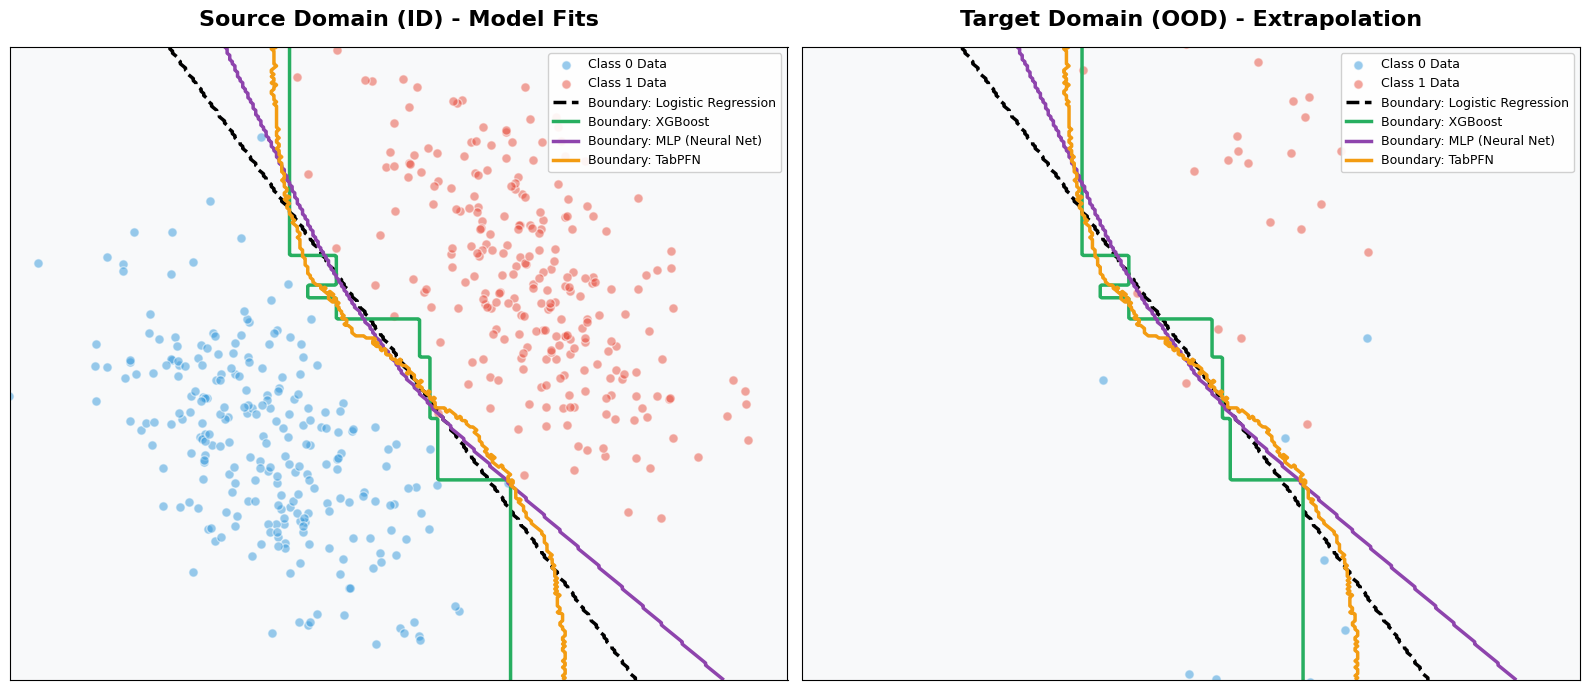

In [10]:
# Create a dictionary of our trained models
trained_models = {
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model,
    'MLP (Neural Net)': mlp_model,
    'TabPFN': tabpfn_model
}

fig, (ax_s, ax_t) = plt.subplots(1, 2, figsize=(16, 7))

color_class_0 = '#3498db'
color_class_1 = '#e74c3c'

# Define distinct colors and styles for each model's boundary line
model_styles = {
    'Logistic Regression': {'color': 'black', 'style': '--'},
    'XGBoost': {'color': '#27ae60', 'style': '-'},      # Green
    'MLP (Neural Net)': {'color': '#8e44ad', 'style': '-'}, # Purple
    'TabPFN': {'color': '#f39c12', 'style': '-'}        # Orange
}

def plot_overlay_boundaries(ax, X_data, y_data, title):
    # Set grid limits based on scaled data
    x_min, x_max = -2.5, 2.5
    y_min, y_max = -2.5, 2.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    
    # Scatter the actual data points
    ax.scatter(X_data[y_data==0, 0], X_data[y_data==0, 1], c=color_class_0, edgecolors='white', alpha=0.5, s=45, label='Class 0 Data')
    ax.scatter(X_data[y_data==1, 0], X_data[y_data==1, 1], c=color_class_1, edgecolors='white', alpha=0.5, s=45, label='Class 1 Data')
    
    # Loop through models and draw ONLY their decision boundaries (Z = 0.5)
    for name, model in trained_models.items():
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        # levels=[0.5] draws the line exactly where the model switches from predicting 0 to 1
        ax.contour(xx, yy, Z, levels=[0.5], colors=[model_styles[name]['color']], 
                   linestyles=model_styles[name]['style'], linewidths=2.5)
        # We use a dummy plot for the legend to represent the line
        ax.plot([], [], color=model_styles[name]['color'], linestyle=model_styles[name]['style'], linewidth=2.5, label=f'Boundary: {name}')

    ax.set_title(title, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('#f8f9fa') # Light gray background for contrast
    
    # Organize the legend
    ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

# Plot Source Only
plot_overlay_boundaries(ax_s, X_source_scaled, y_source_std, "Source Domain (ID) - Model Fits")

# Plot Target Only
plot_overlay_boundaries(ax_t, X_target_scaled, y_target_std, "Target Domain (OOD) - Extrapolation")

plt.tight_layout()
plt.show()

### Systematic Comparison: Model Generalization under Covariate Shift

Visualizing the accuracy side-by-side reveals the strengths and critical extrapolation weaknesses of different architectures across domains:

* **The Source Domain (ID):** All models perform exceptionally well, successfully learning the underlying pattern of the training distribution. Complex models like XGBoost and MLP achieve near-perfect accuracy by flexibly adapting to the non-linear data.
* **The Target Domain (OOD):** The non-linear Covariate Shift provides a rigorous evaluation of out-of-distribution (OOD) generalization. Logistic Regression fails due to its strict linear rigidity. XGBoost's orthogonal splits fail to generalize to the newly inverted curve. Even flexible models like MLP and TabPFN suffer severe performance drops—demonstrating that without domain adaptation, models struggle to extrapolate meaningfully to unseen distributions.

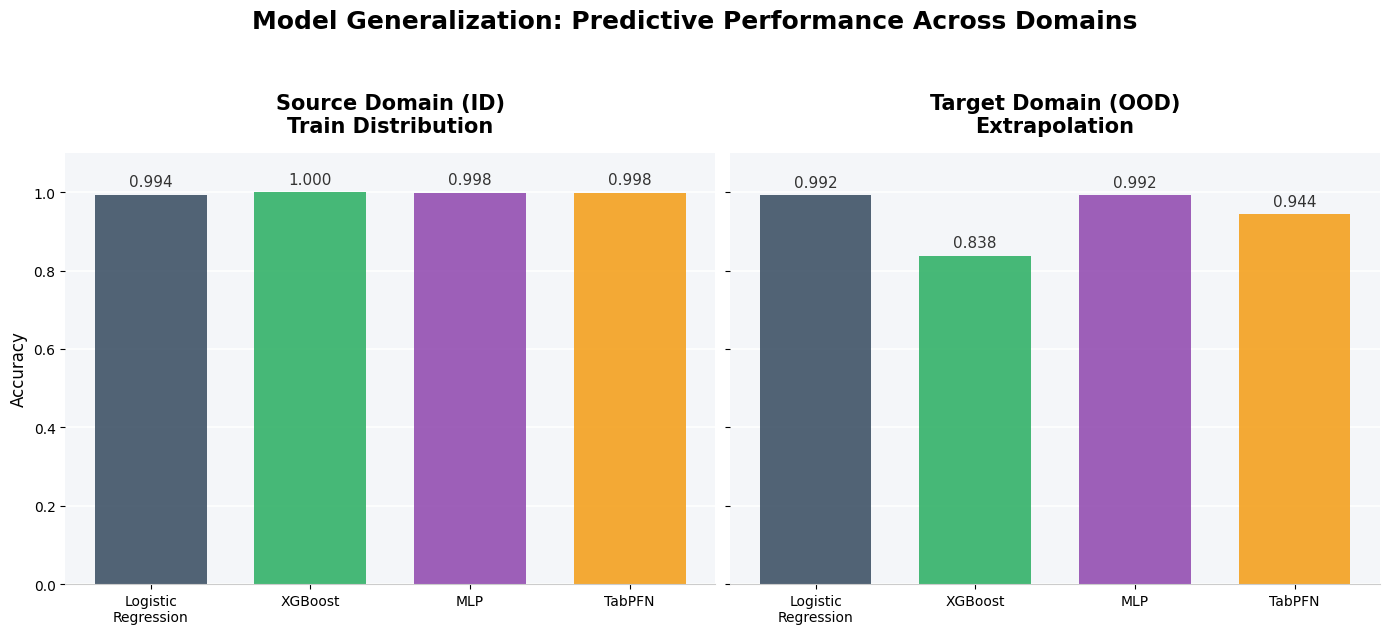

In [11]:
# ==========================================
# 6. Final Performance Comparison Bar Chart
# ==========================================
# Aggregate the accuracies we computed earlier
model_names = ['Logistic\nRegression', 'XGBoost', 'MLP', 'TabPFN']
src_accuracies = [lr_src_acc, xgb_src_acc, mlp_src_acc, tabpfn_src_acc]
tgt_accuracies = [lr_tgt_acc, xgb_tgt_acc, mlp_tgt_acc, tabpfn_tgt_acc]

# We use the exact same color palette defined in the overlay plot
bar_colors = ['#34495e', '#27ae60', '#8e44ad', '#f39c12'] 
# (Dark Slate for LR, Green for XGB, Purple for MLP, Orange for TabPFN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- Plot Source Domain ---
bars_src = ax1.bar(model_names, src_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax1.set_title('Source Domain (ID)\nTrain Distribution', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)

# --- Plot Target Domain ---
bars_tgt = ax2.bar(model_names, tgt_accuracies, color=bar_colors, alpha=0.85, width=0.7)
ax2.set_title('Target Domain (OOD)\nExtrapolation', fontsize=15, fontweight='bold', pad=15)

# Function to automatically attach text labels above each bar
def attach_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='500', color='#333333')

attach_labels(bars_src, ax1)
attach_labels(bars_tgt, ax2)

# Clean Aesthetics
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.1) # Leave headroom for the text labels
    ax.set_facecolor('#f4f6f9') # Soft gray background like ggplot
    ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_axisbelow(True) # Put grid behind bars
    
    # Remove outer spines for a cleaner look
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    # Thicken x-axis line slightly
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')

plt.suptitle("Model Generalization: Predictive Performance Across Domains", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Domain Adaptation: CORAL (Correlation Alignment)

To address the Covariate Shift, we apply the **CORAL** algorithm. CORAL attempts to align the second-order statistics (covariance matrices) of the Source and Target distributions using a linear transformation (scaling, shifting, and rotating).

Before evaluating the models, let's visualize what CORAL physically does to our data. We will compute the transformation and plot the original Source, the Target, and the newly Aligned Source.

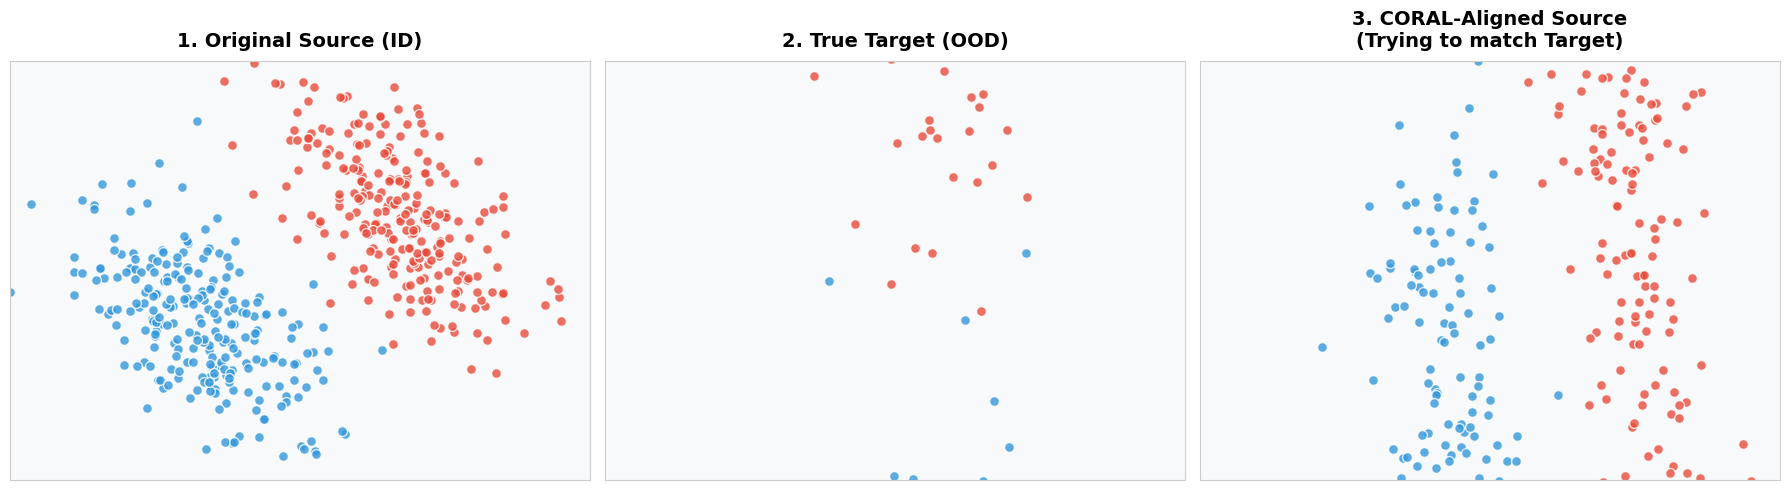

In [12]:
from scipy.linalg import fractional_matrix_power

# ==========================================
# 1. CORAL Algorithm Implementation
# ==========================================
def coral_alignment(X_s, X_t, lambda_reg=1.0):
    d = X_s.shape[1]
    Cs = np.cov(X_s, rowvar=False) + np.eye(d) * lambda_reg
    Ct = np.cov(X_t, rowvar=False) + np.eye(d) * lambda_reg
    
    Cs_inv_sqrt = fractional_matrix_power(Cs, -0.5)
    Ct_sqrt = fractional_matrix_power(Ct, 0.5)
    
    X_s_centered = X_s - np.mean(X_s, axis=0)
    X_s_aligned = X_s_centered @ Cs_inv_sqrt @ Ct_sqrt + np.mean(X_t, axis=0)
    
    return np.real(X_s_aligned)

# Apply CORAL to align scaled Source to scaled Target
X_source_coral = coral_alignment(X_source_scaled, X_target_scaled)

# ==========================================
# 2. Visualize the Transformation
# ==========================================
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
color_blue, color_red = '#3498db', '#e74c3c'

def plot_scatter(ax, X, y, title):
    ax.scatter(X[y==0][:, 0], X[y==0][:, 1], c=color_blue, edgecolors='white', s=50, alpha=0.8, label='Class 0')
    ax.scatter(X[y==1][:, 0], X[y==1][:, 1], c=color_red, edgecolors='white', s=50, alpha=0.8, label='Class 1')
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('#f8f9fa')
    for spine in ax.spines.values(): spine.set_color('#cccccc')

plot_scatter(ax1, X_source_scaled, y_source_std, "1. Original Source (ID)")
plot_scatter(ax2, X_target_scaled, y_target_std, "2. True Target (OOD)")
plot_scatter(ax3, X_source_coral, y_source_std, "3. CORAL-Aligned Source\n(Trying to match Target)")

plt.tight_layout()
plt.show()

**Observation on the CORAL Transformation:**
Looking at the third plot, the transformation appears destructive. The red class is seemingly compressed or pushed out of frame, and the blue class is linearly skewed. 
This visually confirms our hypothesis: CORAL relies on a global, linear transformation (aligning covariance matrices). When faced with a complex, non-linear geometric shift (like interleaving, inverting moons), a purely linear alignment fails to preserve the intricate class boundaries, often crushing the underlying manifold.

### Re-Evaluating Models Post-Alignment

Now that our Source data is aligned with the Target, we retrain all our models on this new `CORAL-Aligned Source` space and test them again on the `Target` domain. 

**Hypothesis:** Because CORAL is a strict *linear* transformation and the shift between the moons is highly *non-linear* (the curve inverts), we hypothesize that CORAL will struggle to provide a perfect fix, but may slightly alter the decision boundaries. Let's observe the impact on Target accuracy across all architectures.

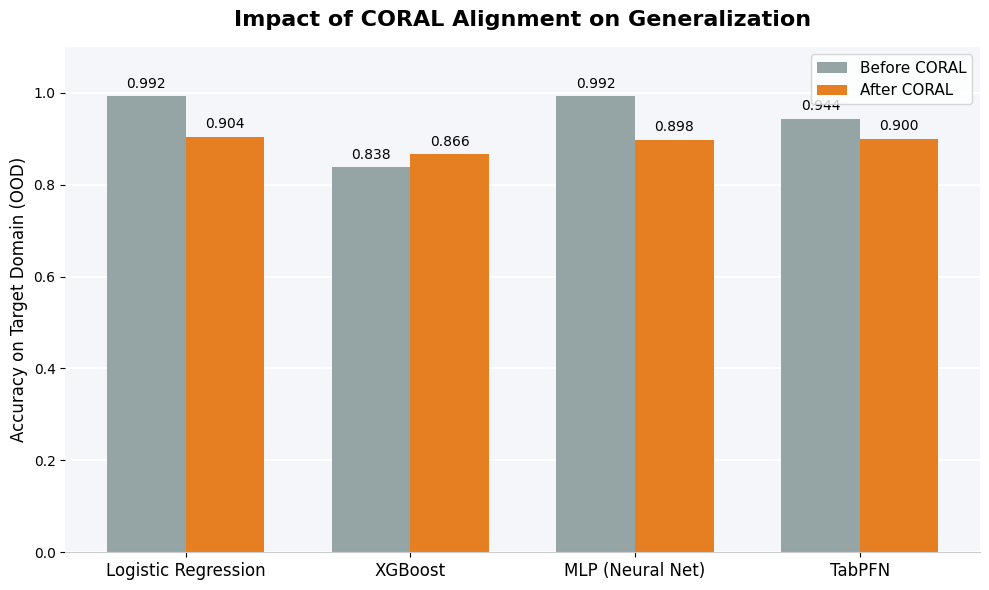

In [13]:
# ==========================================
# 3. Retrain Models & Collect Results
# ==========================================
# Assuming `trained_models` dict from earlier is still in memory
# Example: trained_models = {'Logistic Regression': lr_model, 'XGBoost': xgb_model, ...}

results_before = []
results_after = []
model_names_list = list(trained_models.keys())

for name, model in trained_models.items():
    # 1. Performance BEFORE CORAL (Train on Standard Source)
    model.fit(X_source_scaled, y_source_std)
    acc_before = accuracy_score(y_target_std, model.predict(X_target_scaled))
    results_before.append(acc_before)
    
    # 2. Performance AFTER CORAL (Train on Aligned Source)
    model.fit(X_source_coral, y_source_std)
    acc_after = accuracy_score(y_target_std, model.predict(X_target_scaled))
    results_after.append(acc_after)

# ==========================================
# 4. Plot Grouped Bar Chart
# ==========================================
x = np.arange(len(model_names_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Use distinct colors for Before/After
rects1 = ax.bar(x - width/2, results_before, width, label='Before CORAL', color='#95a5a6')
rects2 = ax.bar(x + width/2, results_after, width, label='After CORAL', color='#e67e22')

ax.set_ylabel('Accuracy on Target Domain (OOD)', fontsize=12)
ax.set_title('Impact of CORAL Alignment on Generalization', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names_list, fontsize=12)
ax.legend(loc='upper right', fontsize=11)
ax.set_ylim(0, 1.1)

# Clean aesthetics
ax.set_facecolor('#f4f6f9')
ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5)
ax.set_axisbelow(True)
for spine in ax.spines.values(): spine.set_visible(False)
ax.spines['bottom'].set_visible(True); ax.spines['bottom'].set_color('#cccccc')

# Function to attach text labels
def attach_labels(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='500')

attach_labels(rects1)
attach_labels(rects2)

plt.tight_layout()
plt.show()

## High-Dimensional Biological Data 

In the real world, especially in domains like bioinformatics, tabular data is rarely confined to a few clean variables. It is often extremely high-dimensional, characterized by having significantly more features ($P$) than samples ($N$). A key challenge in this regime is that the vast majority of these features are irrelevant noise.

**The Simulation Strategy:**
To simulate this environment, we take our 2D informative `Two Moons` dataset (with 500 samples) and append 1998 pure noise features (drawn from a Gaussian distribution). We then apply the exact same Covariate Shift splitting strategy based on the informative feature. 

**The Dual Challenge:**
The models must now tackle two severe problems simultaneously:
1. **Feature Selection:** Avoiding catastrophic overfitting to the 1998 noise dimensions (The Curse of Dimensionality).
2. **Domain Adaptation:** Extrapolating the learned boundary to the unseen Target domain.

**Terminology:**
* **$N$ (Number of Samples):** The number of data points. Here, $N=500$.
* **$P$ (Number of Features):** The total number of dimensions. In this section, $P=2000$ (2 true informative dimensions + 1998 nuisance dimensions).

In [26]:
# ==========================================
# 1. High-Dimensional Data Generation
# ==========================================
N_SAMPLES = 500
P_DIMENSIONS = 2000  # 2 informative features + 98 noise features

# A. Generate the base 2D informative features
X_base_2d, y_base_bio = make_moons(n_samples=N_SAMPLES, noise=0.1, random_state=42)
X_base_2d[:, 0] -= 0.5  # Center the dataset at X=0

# B. Generate nuisance features (pure Gaussian noise)
np.random.seed(42) # For reproducibility
noise_features = np.random.normal(loc=0, scale=1, size=(N_SAMPLES, P_DIMENSIONS - 2))

# C. Concatenate informative features with noise features to create the final dataset
X_base_bio = np.hstack((X_base_2d, noise_features))

print(f"Original 2D Shape: {X_base_2d.shape}")
print(f"High-Dimensional Shape: {X_base_bio.shape}")

# ==========================================
# 2. Domain Split (Using the first informative feature)
# ==========================================
# Source Domain (In-Distribution)
source_mask_bio = X_base_bio[:, 0] <= 0
X_source_bio, y_source_bio = X_base_bio[source_mask_bio], y_base_bio[source_mask_bio]

# Target Domain (Out-of-Distribution) with slight overlap
target_mask_bio = X_base_bio[:, 0] >= -0.1
X_target_bio, y_target_bio = X_base_bio[target_mask_bio], y_base_bio[target_mask_bio]

print(f"\nSource Domain Samples: {len(X_source_bio)}")
print(f"Target Domain Samples: {len(X_target_bio)}")

# ==========================================
# 3. Feature Scaling (Critical for High-Dim and Regularization)
# ==========================================
scaler_bio = StandardScaler()
X_source_bio_scaled = scaler_bio.fit_transform(X_source_bio)
X_target_bio_scaled = scaler_bio.transform(X_target_bio)

Original 2D Shape: (500, 2)
High-Dimensional Shape: (500, 2000)

Source Domain Samples: 255
Target Domain Samples: 266


### Linear Baselines: Standard Logistic Regression vs. LASSO

In high-dimensional spaces where most features are noise, a standard linear model often struggles. We compare standard Logistic Regression (L2 regularization by default) against **LASSO (L1 regularization)**. LASSO is particularly useful here as it acts as an embedded feature selector, driving the weights of irrelevant features exactly to zero.

In [27]:
# Standard Logistic Regression
lr_model_bio = LogisticRegression(random_state=42)
lr_src_acc_bio, lr_tgt_acc_bio = train_and_eval(lr_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

# LASSO Logistic Regression (L1 penalty)
lasso_model_bio = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
lasso_src_acc_bio, lasso_tgt_acc_bio = train_and_eval(lasso_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

# Count retained features for LASSO
retained_features = np.sum(lasso_model_bio.coef_ != 0)
total_features = X_source_bio_scaled.shape[1]

print("--- Source Domain (ID) ---")
print(f"Logistic Regression Accuracy on Source Data: {lr_src_acc_bio:.3f}")
print(f"LASSO (L1) Accuracy on Source Data:          {lasso_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"Logistic Regression Accuracy on Target Data: {lr_tgt_acc_bio:.3f}")
print(f"LASSO (L1) Accuracy on Target Data:          {lasso_tgt_acc_bio:.3f}\n")

print(f"* Note: LASSO retained {retained_features} out of {total_features} features.")

--- Source Domain (ID) ---
Logistic Regression Accuracy on Source Data: 1.000
LASSO (L1) Accuracy on Source Data:          1.000

--- Target Domain (OOD) ---
Logistic Regression Accuracy on Target Data: 0.598
LASSO (L1) Accuracy on Target Data:          0.714

* Note: LASSO retained 65 out of 2000 features.


### Tree-Based Ensemble: XGBoost

Tree-based models generally perform well with uninformative features because they inherently select the most discriminative splits. We expect XGBoost to handle the noise features relatively well during training, but its step-like decision boundaries will still face the fundamental challenge of the non-linear domain shift.

In [28]:
# Initialize and train XGBoost
xgb_model_bio = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

xgb_src_acc_bio, xgb_tgt_acc_bio = train_and_eval(xgb_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"XGBoost Accuracy on Source Data: {xgb_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"XGBoost Accuracy on Target Data: {xgb_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
XGBoost Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
XGBoost Accuracy on Target Data: 0.820



### Neural Networks: Multi-Layer Perceptron (MLP)

Standard MLPs lack built-in feature selection. In high-dimensional spaces with low sample sizes, they are highly prone to memorizing the noise features rather than learning the true underlying signal. We anticipate the MLP will show a significant performance drop compared to its performance on the 2D dataset.

In [29]:
# Initialize and train MLP
mlp_model_bio = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)

mlp_src_acc_bio, mlp_tgt_acc_bio = train_and_eval(mlp_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"MLP Accuracy on Source Data: {mlp_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"MLP Accuracy on Target Data: {mlp_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
MLP Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
MLP Accuracy on Target Data: 0.485



### Foundation Models: TabPFN

We evaluate how TabPFN handles high-dimensional noise. While its attention mechanism might help focus on relevant features, Transformers can also struggle when the noise-to-signal ratio is extreme.

**Note on TabPFN Usage:**
Remember to ensure your API token is active.

In [30]:
# Initialize TabPFN (assuming token is already set in the environment from Part 1)
tabpfn_model_bio = TabPFNClassifier(device="cpu") 

# Train & Evaluate
tabpfn_src_acc_bio, tabpfn_tgt_acc_bio = train_and_eval(tabpfn_model_bio, X_source_bio_scaled, y_source_bio, X_target_bio_scaled, y_target_bio)

print("--- Source Domain (ID) ---")
print(f"TabPFN Accuracy on Source Data: {tabpfn_src_acc_bio:.3f}\n")

print("--- Target Domain (OOD) ---")
print(f"TabPFN Accuracy on Target Data: {tabpfn_tgt_acc_bio:.3f}\n")

--- Source Domain (ID) ---
TabPFN Accuracy on Source Data: 1.000

--- Target Domain (OOD) ---
TabPFN Accuracy on Target Data: 0.827



### Systematic Comparison: High-Dimensional Model Generalization

Visualizing the accuracy side-by-side reveals how the dual challenge of Domain Shift and Extreme Dimensionality impacts these models:

* **The Dimensionality Curse:** Unlike the 2D case, standard linear models and MLPs struggle heavily when flooded with noise. LASSO demonstrates the critical importance of feature selection in these scenarios.
* **The Extrapolation Failure:** Even if a model successfully ignores the noise (like XGBoost or LASSO), it still fails to generalize to the Target domain due to the underlying non-linear distribution shift.

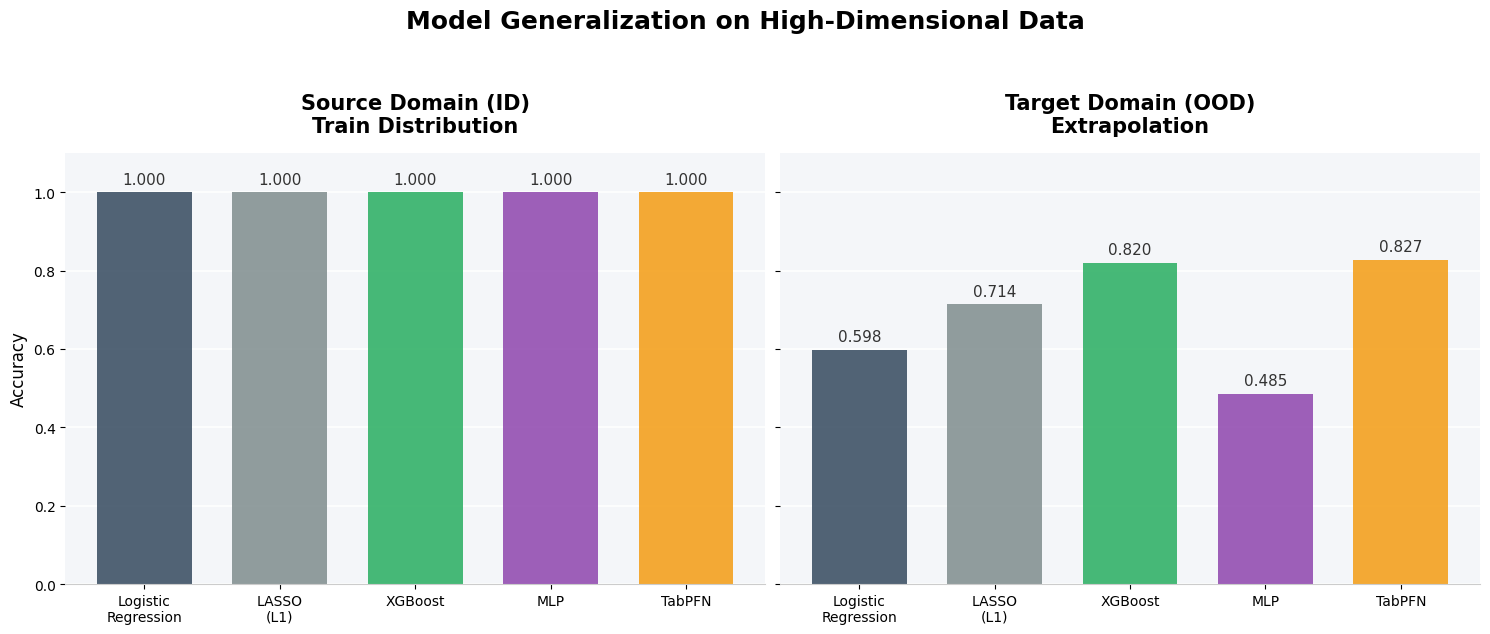

In [31]:
# ==========================================
# Final Performance Comparison Bar Chart (High-Dimensional)
# ==========================================
# Define a fresh function for this specific cell to avoid memory conflicts
def attach_labels_bio(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4),  # 4 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, fontweight='500', color='#333333')

# Aggregate the accuracies (Including LASSO this time)
model_names_bio = ['Logistic\nRegression', 'LASSO\n(L1)', 'XGBoost', 'MLP', 'TabPFN']
src_accuracies_bio = [lr_src_acc_bio, lasso_src_acc_bio, xgb_src_acc_bio, mlp_src_acc_bio, tabpfn_src_acc_bio]
tgt_accuracies_bio = [lr_tgt_acc_bio, lasso_tgt_acc_bio, xgb_tgt_acc_bio, mlp_tgt_acc_bio, tabpfn_tgt_acc_bio]

bar_colors_bio = ['#34495e', '#7f8c8d', '#27ae60', '#8e44ad', '#f39c12'] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# --- Plot Source Domain ---
bars_src_bio = ax1.bar(model_names_bio, src_accuracies_bio, color=bar_colors_bio, alpha=0.85, width=0.7)
ax1.set_title('Source Domain (ID)\nTrain Distribution', fontsize=15, fontweight='bold', pad=15)
ax1.set_ylabel('Accuracy', fontsize=12)

# --- Plot Target Domain ---
bars_tgt_bio = ax2.bar(model_names_bio, tgt_accuracies_bio, color=bar_colors_bio, alpha=0.85, width=0.7)
ax2.set_title('Target Domain (OOD)\nExtrapolation', fontsize=15, fontweight='bold', pad=15)

# Use the newly defined function
attach_labels_bio(bars_src_bio, ax1)
attach_labels_bio(bars_tgt_bio, ax2)

# Clean Aesthetics
for ax in [ax1, ax2]:
    ax.set_ylim(0, 1.1) 
    ax.set_facecolor('#f4f6f9') 
    ax.grid(axis='y', color='white', linestyle='-', linewidth=1.5, alpha=0.8)
    ax.set_axisbelow(True) 
    
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('#cccccc')

plt.suptitle("Model Generalization on High-Dimensional Data", fontsize=18, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()